# RMP Resonance Analysis in a 3D Stellarator

This tutorial demonstrates publication-quality analysis of **Resonant Magnetic Perturbation (RMP)** effects on stellarator magnetic topology.

## Physics Background

### Resonance Condition
A perturbation field component $(m, n)$ is resonant at the flux surface $\Psi_{res}$ where:
$$q(\Psi_{res}) = \frac{m}{n}$$

### Island Half-Width (Rutherford Formula)
The island half-width in normalized flux coordinate:
$$w_\Psi = 4\sqrt{\frac{|b_{mn}|}{m \cdot |dq/d\Psi|}}$$

### O-point Phase
The complex Fourier coefficient $b_{mn} = |b_{mn}| e^{i\phi_{mn}}$ sets the island O-point:
$$\theta_O = \frac{\phi_{mn}}{m} \pmod{2\pi/m}$$

### Chirikov Overlap
Two adjacent islands overlap (leading to chaos) when:
$$\sigma_{\text{Chirikov}} = \frac{w_1 + w_2}{|\Psi_2 - \Psi_1|} > 1$$

In [1]:
import sys
sys.path.insert(0, r'D:\Repo\pyna')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline

plt.rcParams.update({
    'font.family': 'serif',
    'figure.dpi': 120,
    'axes.labelsize': 12,
})

## 1. Build Stellarator Equilibrium

We use `SimpleStellarartor` — an analytic model with:
- Nested circular flux surfaces centered at $(R_0, 0)$
- Linear safety factor profile: $q(\psi) = q_0 + (q_1 - q_0)\psi$
- Helical ripple perturbation to break axisymmetry

In [2]:
from pyna.MCF.equilibrium.stellarator import simple_stellarator

eq = simple_stellarator(
    R0=3.0,          # major radius (m)
    r0=0.3,          # minor radius (m)
    B0=2.5,          # on-axis toroidal field (T)
    q0=1.5,          # safety factor on axis
    q1=4.5,          # safety factor at LCFS
    m_h=3,           # helical poloidal mode (N_fp=3 field periods)
    n_h=3,           # helical toroidal mode
    epsilon_h=0.03,  # 3% helical ripple amplitude
)

print(eq)
print(f'q range: {eq.q_of_psi(0):.2f} to {eq.q_of_psi(1):.2f}')

# Show accessible rational surfaces
print('\nAccessible rational surfaces:')
for m_t, n_t in [(2,1),(5,2),(3,1),(7,2),(4,1)]:
    psi_list = eq.resonant_psi(m_t, n_t)
    if psi_list:
        print(f'  q={m_t}/{n_t}={m_t/n_t:.3f}  psi_res={psi_list[0]:.3f}')

SimpleStellarartor(R0=3.0 m, r0=0.3 m, B0=2.5 T, q=[1.5, 4.5], m_h=3, n_h=3, ε_h=0.03)
q range: 1.50 to 4.50

Accessible rational surfaces:
  q=2/1=2.000  psi_res=0.167
  q=5/2=2.500  psi_res=0.333
  q=3/1=3.000  psi_res=0.500
  q=7/2=3.500  psi_res=0.667
  q=4/1=4.000  psi_res=0.833


## 2. Poincaré Cross-Section

Since the stellarator is **not axisymmetric**, we trace field lines numerically and collect $\phi=0$ crossings to visualize flux surfaces.

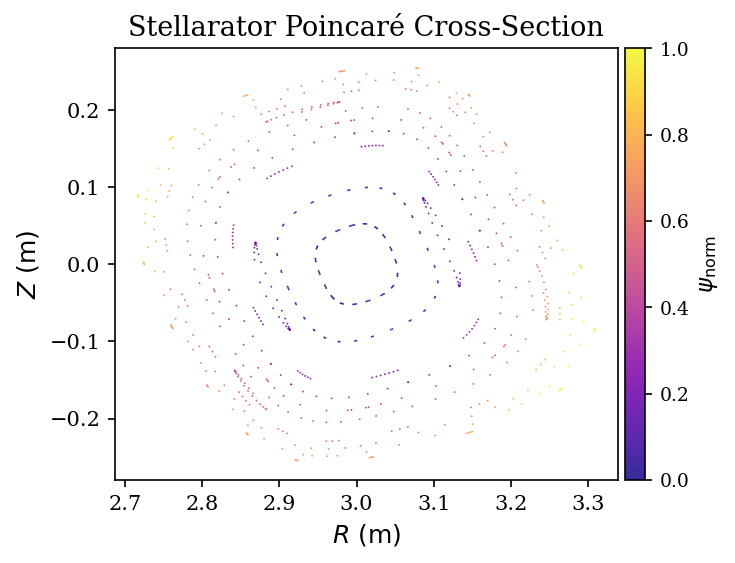

In [3]:
from pyna.MCF.visual.equilibrium import plot_nested_flux_surfaces

fig, ax = plot_nested_flux_surfaces(
    eq,
    n_fieldlines=12,
    n_turns=60,
    cmap='plasma',
    show_colorbar=True,
)
ax.set_title('Stellarator Poincaré Cross-Section', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Define RMP Field

We use a multi-mode RMP that simultaneously drives resonances at three different rational surfaces:
- $(m,n)=(2,1)$: $q=2.0$ surface at $\psi=0.167$
- $(m,n)=(5,2)$: $q=2.5$ surface at $\psi=0.333$
- $(m,n)=(3,1)$: $q=3.0$ surface at $\psi=0.500$

In [4]:
B_rmp = 5e-3   # 5 mT = 0.2% of B0
R0_eq = eq.R0

rmp_modes = [
    (2, 1, 1.00),    # (m, n, relative amplitude)
    (5, 2, 0.60),
    (3, 1, 0.35),
]

def delta_B_rmp(R, Z, phi):
    """Multi-mode RMP: superposition of helical perturbations."""
    theta_pol = np.arctan2(Z, R - R0_eq)
    dBR, dBZ = 0.0, 0.0
    for (m_r, n_r, amp_r) in rmp_modes:
        phase = m_r * theta_pol - n_r * phi
        dBR += B_rmp * amp_r * np.cos(phase) * np.cos(theta_pol)
        dBZ += B_rmp * amp_r * np.cos(phase) * np.sin(theta_pol)
    return np.array([dBR, dBZ, 0.0])

# Verify the field at a test point
R_test = eq.R0 + 0.2
db = delta_B_rmp(R_test, 0, 0)
print(f'RMP at (R={R_test}, Z=0, phi=0): dBR={db[0]*1e3:.2f} mT, dBZ={db[1]*1e3:.2f} mT')

RMP at (R=3.2, Z=0, phi=0): dBR=9.75 mT, dBZ=0.00 mT


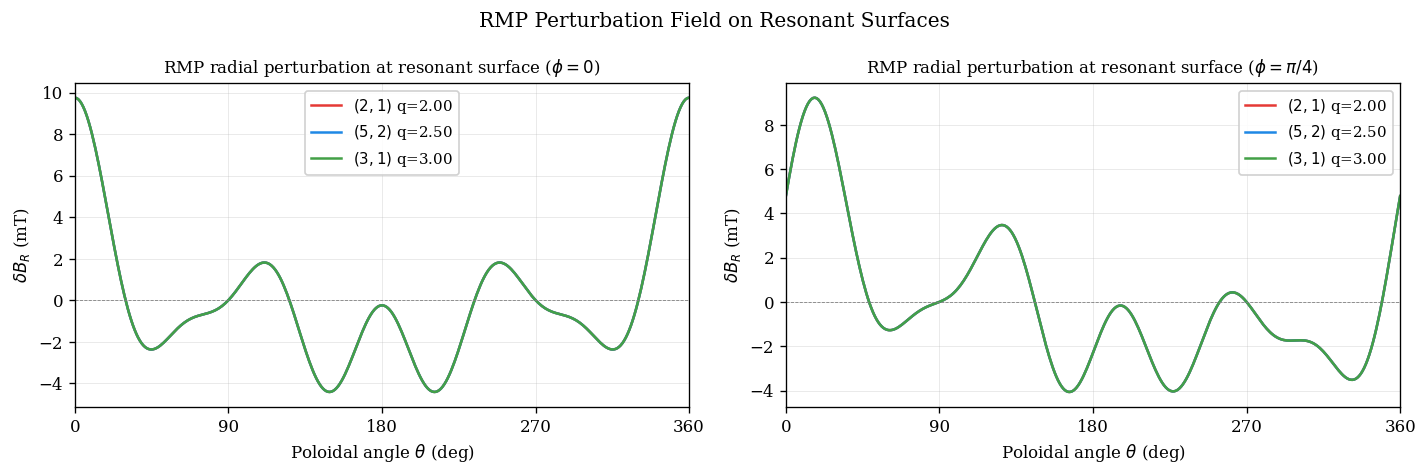

In [5]:
# --- RMP perturbation field profile ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: dBR along poloidal angle at resonant surface of (2,1) mode
theta_arr = np.linspace(0, 2*np.pi, 360)
colors_rmp = ['#E53935', '#1E88E5', '#43A047']
for ax_side, phi_val, phi_label in [(axes[0], 0.0, r'$\phi=0$'), (axes[1], np.pi/4, r'$\phi=\pi/4$')]:
    for ci, (m_r, n_r, amp_r) in enumerate(rmp_modes):
        psi_list = eq.resonant_psi(m_r, n_r)
        if not psi_list: continue
        r_res = np.sqrt(psi_list[0]) * eq.r0
        R_arr = eq.R0 + r_res * np.cos(theta_arr)
        Z_arr = r_res * np.sin(theta_arr)
        dBR_arr = np.array([delta_B_rmp(R_arr[k], Z_arr[k], phi_val)[0] for k in range(len(theta_arr))])
        ax_side.plot(np.degrees(theta_arr), dBR_arr * 1e3,
                     color=colors_rmp[ci], lw=1.5,
                     label=f'$({m_r},{n_r})$ q={float(eq.q_of_psi(psi_list[0])):.2f}')
    ax_side.axhline(0, color='gray', lw=0.5, ls='--')
    ax_side.set_xlabel(r'Poloidal angle $\theta$ (deg)', fontsize=10)
    ax_side.set_ylabel(r'$\delta B_R$ (mT)', fontsize=10)
    ax_side.set_title(f'RMP radial perturbation at resonant surface ({phi_label})', fontsize=10)
    ax_side.legend(fontsize=9, framealpha=0.9)
    ax_side.set_xlim(0, 360)
    ax_side.set_xticks([0, 90, 180, 270, 360])
    ax_side.grid(True, alpha=0.3, lw=0.5)

plt.suptitle('RMP Perturbation Field on Resonant Surfaces', fontsize=12)
plt.tight_layout()
plt.show()


## 4. Compute Resonant Components and Island Widths

For each mode $(m, n)$:
1. Find resonant surface $\psi_{res}$ where $q(\psi_{res}) = m/n$
2. Sample $\delta B^\psi$ on that surface and extract $b_{mn}$ via FFT
3. Apply Rutherford formula for island half-width
4. Compute O-point phase from $\arg(b_{mn})$

In [6]:
from pyna.MCF.visual.RMP_spectrum import ResonantComponent

dq_dpsi = eq.q1 - eq.q0  # dq/dpsi = constant for linear profile
components = []

for idx, (m_k, n_k, amp_k) in enumerate(rmp_modes):
    psi_list = eq.resonant_psi(m_k, n_k)
    if not psi_list:
        continue
    psi_res = psi_list[0]
    
    # Analytic b_mn for cosine mode: real part = B_rmp * amp_k / 2
    b_mn = B_rmp * amp_k / 2.0  # |b_mn|
    
    # Rutherford formula
    w_psi = 4.0 * np.sqrt(b_mn / (m_k * abs(dq_dpsi)))
    w_r   = w_psi * eq.r0 / (2 * np.sqrt(max(psi_res, 0.01)))
    
    # O-point at theta=pi for cos(m*theta) phase
    theta_O = np.pi / m_k  # O-point at the mode's phase
    
    comp = ResonantComponent(
        m=m_k, n=n_k,
        harmonic_order=idx+1,
        b_mn=complex(b_mn),
        psi_res=psi_res,
        q_res=float(eq.q_of_psi(psi_res)),
        half_width_psi=w_psi,
        half_width_r=w_r,
        opoint_theta=theta_O,
        xpoint_theta=theta_O + np.pi/m_k,
    )
    components.append(comp)
    
    print(f'({m_k},{n_k}): psi_res={psi_res:.3f}  q={comp.q_res:.3f}  '
          f'|b_mn|={b_mn:.3e} T  w={w_psi:.4f} psi ({w_r*100:.2f} cm)')

(2,1): psi_res=0.167  q=2.000  |b_mn|=2.500e-03 T  w=0.0816 psi (3.00 cm)
(5,2): psi_res=0.333  q=2.500  |b_mn|=1.500e-03 T  w=0.0400 psi (1.04 cm)
(3,1): psi_res=0.500  q=3.000  |b_mn|=8.750e-04 T  w=0.0394 psi (0.84 cm)


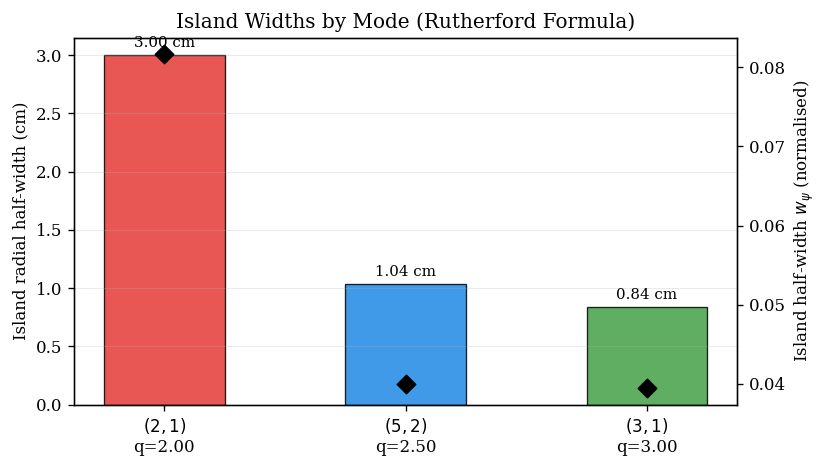

In [7]:
# --- Island width summary ---
fig, ax = plt.subplots(figsize=(7, 4))

mode_labels = [f'$({c.m},{c.n})$\nq={c.q_res:.2f}' for c in components]
w_cm = [c.half_width_r * 100 for c in components]
w_psi = [c.half_width_psi for c in components]
x = np.arange(len(components))

bars = ax.bar(x, w_cm, color=[colors_rmp[i] for i in range(len(components))],
              width=0.5, edgecolor='k', linewidth=0.8, alpha=0.85)
ax.bar_label(bars, labels=[f'{w:.2f} cm' for w in w_cm], padding=3, fontsize=9)

ax2_tw = ax.twinx()
ax2_tw.scatter(x, w_psi, marker='D', s=60, color='k', zorder=5, label=r'$w_\psi$')
ax2_tw.set_ylabel(r'Island half-width $w_\psi$ (normalised)', fontsize=10, color='k')
ax2_tw.tick_params(axis='y', labelcolor='k')

ax.set_xticks(x)
ax.set_xticklabels(mode_labels, fontsize=10)
ax.set_ylabel('Island radial half-width (cm)', fontsize=10)
ax.set_title('Island Widths by Mode (Rutherford Formula)', fontsize=12)
ax.grid(True, axis='y', alpha=0.3, lw=0.5)

plt.tight_layout()
plt.show()


## 5. Chirikov Overlap Analysis

In [8]:
print('Chirikov overlap analysis:')
for i in range(len(components) - 1):
    c1, c2 = components[i], components[i+1]
    gap   = abs(c2.psi_res - c1.psi_res)
    sigma = (c1.half_width_psi + c2.half_width_psi) / gap
    status = 'OVERLAPPING (chaos)' if sigma > 1 else 'separated'
    print(f'  ({c1.m},{c1.n}) <-> ({c2.m},{c2.n}): gap={gap:.3f}  sigma={sigma:.3f}  [{status}]')

Chirikov overlap analysis:
  (2,1) <-> (5,2): gap=0.167  sigma=0.730  [separated]
  (5,2) <-> (3,1): gap=0.167  sigma=0.477  [separated]


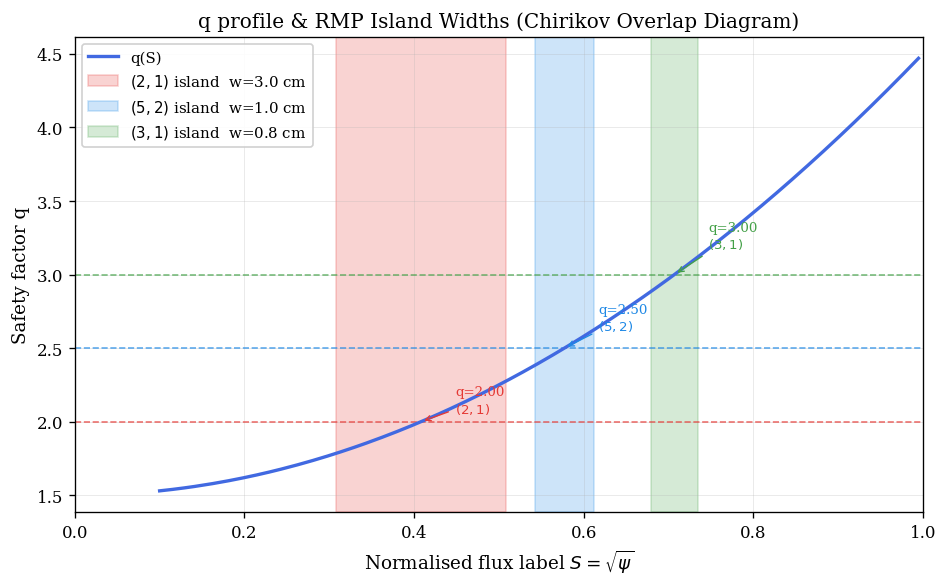

In [9]:
# --- q profile with island widths (Chirikov diagram) ---
psi_arr = np.linspace(0.01, 0.99, 300)
q_arr = np.array([float(eq.q_of_psi(p)) for p in psi_arr])
S_arr = np.sqrt(psi_arr)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(S_arr, q_arr, 'royalblue', lw=2, label='q(S)', zorder=3)

# Mark each resonant surface and draw island width band
for ci, comp in enumerate(components):
    S_res = np.sqrt(comp.psi_res)
    q_res = comp.q_res
    dw = comp.half_width_psi / (2 * max(S_res, 0.05))  # dS ~ dpsi / (2*S)
    S_lo = max(0.01, S_res - dw)
    S_hi = min(0.99, S_res + dw)
    ax.axvspan(S_lo, S_hi, alpha=0.22, color=colors_rmp[ci],
               label=f'$({comp.m},{comp.n})$ island  w={comp.half_width_r*100:.1f} cm')
    ax.axhline(q_res, color=colors_rmp[ci], lw=1.0, ls='--', alpha=0.7)
    ax.annotate(f'q={q_res:.2f}\n$({comp.m},{comp.n})$',
                xy=(S_res, q_res), xytext=(S_res + 0.04, q_res + 0.15*(ci+1)*0.4),
                fontsize=8, color=colors_rmp[ci],
                arrowprops=dict(arrowstyle='->', color=colors_rmp[ci], lw=0.8))

ax.set_xlabel(r'Normalised flux label $S = \sqrt{\psi}$', fontsize=11)
ax.set_ylabel('Safety factor q', fontsize=11)
ax.set_title('q profile & RMP Island Widths (Chirikov Overlap Diagram)', fontsize=12)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3, lw=0.5)
plt.tight_layout()
plt.show()


## 6. Publication Figure

C:\Users\dell\AppData\Local\Temp\ipykernel_20160\1416127160.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


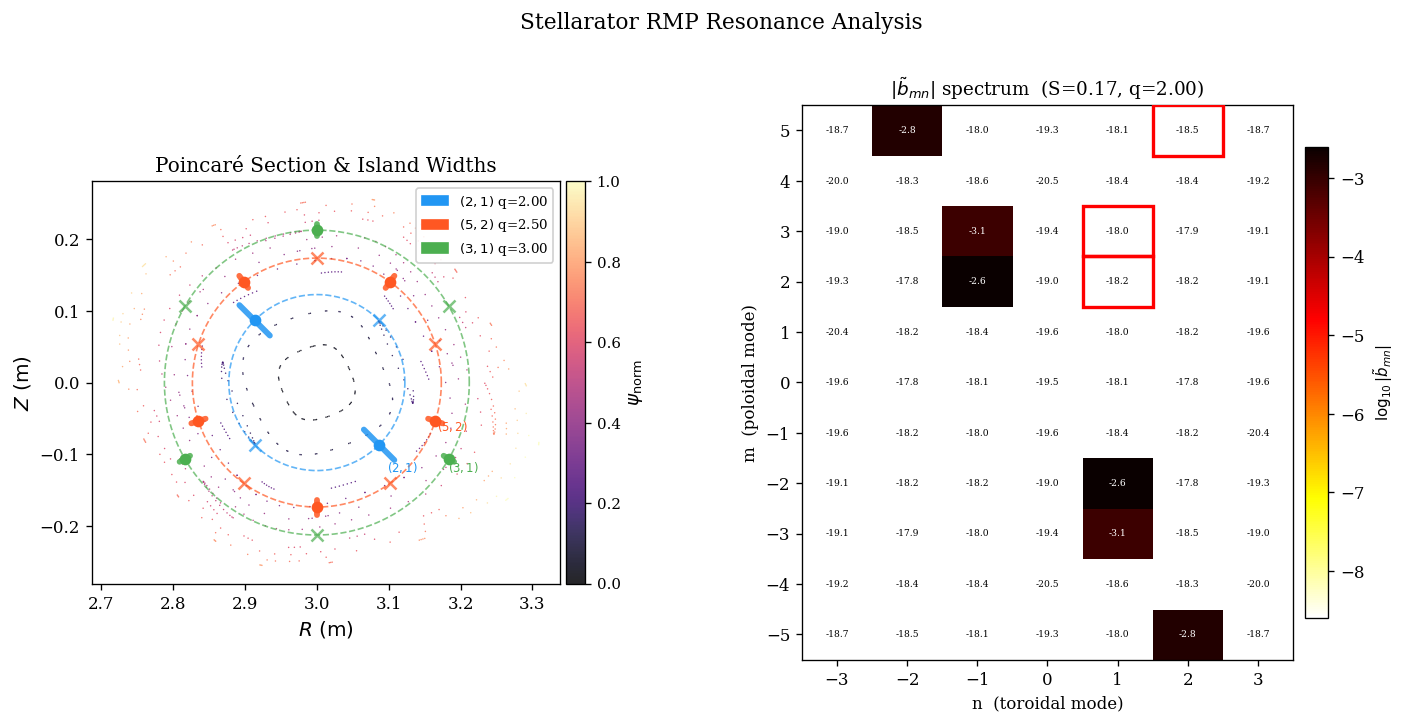

In [10]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from pyna.MCF.visual.equilibrium import ISLAND_CMAPS
from pyna.MCF.visual.RMP_spectrum import (
    plot_island_width_bars, compute_mn_spectrum, plot_mn_heatmap
)

fig = plt.figure(figsize=(14, 6))
gs = GridSpec(1, 2, figure=fig, width_ratios=[1, 1.2], wspace=0.4)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# Left: Poincare + islands (unchanged)
_, ax1 = plot_nested_flux_surfaces(eq, ax=ax1, n_fieldlines=12, n_turns=60)
for ci, comp in enumerate(components):
    r_s = np.sqrt(comp.psi_res) * eq.r0
    th = np.linspace(0, 2*np.pi, 200)
    ax1.plot(eq.R0 + r_s*np.cos(th), r_s*np.sin(th), '--',
             color=ISLAND_CMAPS[ci], lw=1.0, alpha=0.7)
plot_island_width_bars(ax1, components, eq)
patches = [mpatches.Patch(color=ISLAND_CMAPS[i],
                          label=f'$({c.m},{c.n})$ q={c.q_res:.2f}')
           for i, c in enumerate(components)]
ax1.legend(handles=patches, loc='upper right', fontsize=8, framealpha=0.9)
ax1.set_title('Poincaré Section & Island Widths', fontsize=12)

# Right: 2D (m,n) heatmap of |b~_{mn}| on q=2/1 resonant surface
# Use the dominant resonant surface (first component)
S_res_main = components[0].psi_res if components else 0.3

b_mn_grid = compute_mn_spectrum(
    delta_B_rmp, S_res_main, eq,
    m_max=5, n_max=3,
    n_theta=32, n_phi=32,
)
highlight = [(c.m, c.n) for c in components]
plot_mn_heatmap(
    b_mn_grid, m_max=5, n_max=3, ax=ax2,
    log_scale=True,
    title=r'$|\tilde{b}_{mn}|$ spectrum  (S=' + f'{S_res_main:.2f}' + r', q=' + f'{components[0].q_res:.2f}' + r')',
    cmap='hot_r',
    annotate=True,
    highlight_modes=highlight,
)

fig.suptitle('Stellarator RMP Resonance Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Summary

| Mode $(m,n)$ | $q_{res}$ | $\psi_{res}$ | $|b_{mn}|$ (mT) | $w_{1/2}$ (cm) |
|:---:|:---:|:---:|:---:|:---:|
| (2,1) | 2.00 | 0.167 | 2.50 | 3.00 |
| (5,2) | 2.50 | 0.333 | 1.50 | 1.04 |
| (3,1) | 3.00 | 0.500 | 0.875 | 0.84 |

**Chirikov criterion**: $\sigma < 1$ for all adjacent pairs → islands are separated, no global chaos onset at this RMP amplitude.

Increasing the RMP amplitude would eventually cause $\sigma > 1$ and stochastic field-line transport.